# BTC Price Forecasting

## Notebook 3 — Model Training & Evaluation

This notebook builds, trains and evaluates the RNN model.
The raw data and preprocessing are complete — we load the scaled arrays
produced in Notebook 2 and focus entirely on the model.

### What we are building

A recurrent neural network that looks at the last 24 hours of BTC price
and volume data and predicts the closing price at the end of the next hour.

- **Input:** 1,440 consecutive minutes × 6 features
- **Output:** 1 value — the scaled Close price 60 minutes ahead
- **Architecture:** LSTM with Dropout regularisation
- **Loss function:** Mean Squared Error (MSE)

### Steps

1. **Setup** — imports, mount Drive, load scaled arrays and scaler
2. **Build tf.data pipelines** — stream sliding windows directly from the scaled arrays without RAM constraints
3. **Inspect pipelines** — verify shapes and sample batches before training
4. **Define model** — LSTM architecture with Dropout and Dense output layer
5. **Train** — fit with EarlyStopping and ModelCheckpoint callbacks
6. **Evaluate** — compute MSE and MAE on the test set, inverse-transform to USD
7. **Visualise** — loss curves and actual vs predicted price chart
8. **Save** — export `model.h5` and `predictions.json` for the dashboard


### Key concept — why tf.data

In Notebook 2 we built windows by materialising the full numpy array in RAM.
With stride=1 that crashed Colab. Here we use `tf.data.Dataset` to stream
windows one batch at a time directly from the scaled arrays — the full window
array is never held in memory. This is the correct production pattern for
any dataset that does not fit in RAM.

> The only files this notebook reads are:
> `train_scaled.npy`, `val_scaled.n

## Setup

Import libraries, mount Google Drive and load the preprocessed arrays
produced in Notebook 2.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle
import os

# ── Paths ──────────────────────────────────────────────────────
PROCESSED_DIR = '/content/drive/MyDrive/TimeSeriesForecasting/processed'
OUT_DIR       = '/content/drive/MyDrive/TimeSeriesForecasting/model'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Windowing config (must match Notebook 2) ───────────────────
WINDOW_SIZE = 1440   # 24h lookback
HORIZON     = 60     # predict 1h ahead
BATCH_SIZE  = 32
CLOSE_IDX   = 0      # position of Close in feature matrix

# ── Load scaled arrays ─────────────────────────────────────────
print('Loading scaled arrays...')
train_scaled = np.load(os.path.join(PROCESSED_DIR, 'train_scaled.npy'))
val_scaled   = np.load(os.path.join(PROCESSED_DIR, 'val_scaled.npy'))
test_scaled  = np.load(os.path.join(PROCESSED_DIR, 'test_scaled.npy'))

print(f'  train_scaled : {train_scaled.shape}')
print(f'  val_scaled   : {val_scaled.shape}')
print(f'  test_scaled  : {test_scaled.shape}')

# ── Load scaler ────────────────────────────────────────────────
with open(os.path.join(PROCESSED_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)

print()
print(f'TensorFlow version : {tf.__version__}')
print('Setup complete ✓')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading scaled arrays...
  train_scaled : (786240, 6)
  val_scaled   : (152640, 6)
  test_scaled  : (122287, 6)

TensorFlow version : 2.19.0
Setup complete ✓


## Step 2 — Build tf.data pipelines

Instead of materialising millions of windows as numpy arrays,
we use `tf.data.Dataset` to stream windows one batch at a time.

The `.window()` method slides across the scaled array and yields
subsequences lazily — only the current batch is ever in memory.
This is how production time series pipelines handle large datasets.

Each pipeline:
- Slides a window of 1,440 + 60 rows across the data
- Splits each window into `X` (first 1,440 rows) and `y` (Close value at row 1,500)
- Shuffles training data only — val and test preserve time order
- Batches and prefetches for efficient GPU utilisation

In [ ]:
def make_dataset(data, window_size, horizon, batch_size, shuffle=False, shift=60):
    total_length = window_size + horizon
    dataset = tf.data.Dataset.from_tensor_slices(data)

    dataset = dataset.window(total_length, shift=shift, drop_remainder=True)

    dataset = dataset.flat_map(
        lambda w: w.batch(total_length, drop_remainder=True)
    )

    dataset = dataset.map(
        lambda w: (w[:window_size], w[window_size + horizon - 1, CLOSE_IDX]),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(buffer_size=2000, seed=42)

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset


print('Building tf.data pipelines (shift=60)...')

train_ds = make_dataset(train_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE, shuffle=True,  shift=60)
val_ds   = make_dataset(val_scaled,   WINDOW_SIZE, HORIZON, BATCH_SIZE, shuffle=False, shift=60)
test_ds  = make_dataset(test_scaled,  WINDOW_SIZE, HORIZON, BATCH_SIZE, shuffle=False, shift=60)

# Verify shapes
for name, ds in [('train_ds', train_ds), ('val_ds', val_ds), ('test_ds', test_ds)]:
    for X_batch, y_batch in ds.take(1):
        print(f'  {name} — X: {X_batch.shape}  y: {y_batch.shape}')

print()
print('Pipelines ready ✓')

Building tf.data pipelines (shift=60)...
  train_ds — X: (32, 1440, 6)  y: (32,)
  val_ds — X: (32, 1440, 6)  y: (32,)
  test_ds — X: (32, 1440, 6)  y: (32,)

Pipelines ready ✓



## Step 3 — Inspect pipelines

Before training we verify the pipelines are producing the correct shapes.
A single batch is pulled from each dataset and inspected — if the shapes
are wrong here, training will fail or silently produce incorrect results.

In [ ]:
print('Inspecting pipelines...')
print()

for name, ds in [('train_ds', train_ds), ('val_ds', val_ds), ('test_ds', test_ds)]:
    for X_batch, y_batch in ds.take(1):
        print(f'  {name}')
        print(f'    X batch shape : {X_batch.shape}  → (batch, timesteps, features)')
        print(f'    y batch shape : {y_batch.shape}  → (batch,)')
        print(f'    X min / max   : {X_batch.numpy().min():.4f} / {X_batch.numpy().max():.4f}')
        print(f'    y min / max   : {y_batch.numpy().min():.4f} / {y_batch.numpy().max():.4f}')
        print()

print('Expected X shape : (32, 1440, 6)')
print('Expected y shape : (32,)')
print()
print('Inspection complete ✓')

Inspecting pipelines...

  train_ds
    X batch shape : (32, 1440, 6)  → (batch, timesteps, features)
    y batch shape : (32,)  → (batch,)
    X min / max   : 0.0000 / 1.0000
    y min / max   : 0.0389 / 0.0647

  val_ds
    X batch shape : (32, 1440, 6)  → (batch, timesteps, features)
    y batch shape : (32,)  → (batch,)
    X min / max   : 0.0000 / 1.0000
    y min / max   : 0.3163 / 0.3342

  test_ds
    X batch shape : (32, 1440, 6)  → (batch, timesteps, features)
    y batch shape : (32,)  → (batch,)
    X min / max   : 0.0000 / 1.0000
    y min / max   : 0.3224 / 0.3257

Expected X shape : (32, 1440, 6)
Expected y shape : (32,)

Inspection complete ✓


## Step 4 — Define the model

We use a stacked LSTM architecture — the standard starting point for
sequence regression tasks. The first LSTM layer returns the full sequence
so the second layer can learn higher-level temporal patterns.
Dropout between layers reduces overfitting on the training set.

**Architecture**
- `LSTM(64)` — learns short and medium-term price patterns
- `Dropout(0.2)` — randomly drops 20% of units during training
- `LSTM(32)` — compresses sequence into a compact representation
- `Dropout(0.2)` — second regularisation layer
- `Dense(1)` — outputs a single scaled price value

**Loss:** Mean Squared Error (MSE) — as required  
**Optimizer:** Adam with default learning rate  
**Metric:** MAE — more interpretable in USD after inverse-transform

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential([
    Input(shape=(WINDOW_SIZE, 6)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1440, 64)       │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1440, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Train the model

We train with two callbacks:
- **EarlyStopping** — stops training if validation loss stops improving,
  restores the best weights automatically
- **ModelCheckpoint** — saves the best model to disk during training
  so we never lose it if the session crashes


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model_path = os.path.join(OUT_DIR, 'model.keras')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=model_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print('Starting training...')
print(f'  Model will be saved → {model_path}')
print()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

print()
print('Training complete ✓')

Starting training...
  Model will be saved → /content/drive/MyDrive/TimeSeriesForecasting/model/model.keras

Epoch 1/50
    409/Unknown 49s 106ms/step - loss: 0.0025 - mae: 0.0372

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.00009, saving model to /content/drive/MyDrive/TimeSeriesForecasting/model/model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TimeSeriesForecasting/model/model.keras
409/409 ━━━━━━━━━━━━━━━━━━━━ 54s 118ms/step - loss: 0.0023 - mae: 0.0355 - val_loss: 9.3912e-05 - val_mae: 0.0079
Epoch 2/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 6.3070e-04 - mae: 0.0174
Epoch 2: val_loss did not improve from 0.00009
409/409 ━━━━━━━━━━━━━━━━━━━━ 81s 119ms/step - loss: 0.0011 - mae: 0.0231 - val_loss: 1.4690e-04 - val_mae: 0.0108
Epoch 3/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 4.6196e-04 - mae: 0.0140
Epoch 3: val_loss improved from 0.00009 to 0.00005, saving model to /content/drive/MyDrive/TimeSeriesForecasting/model/model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/TimeSeriesForecasting/model/model.keras
409/409 ━━━━━━━━━━━━━━━━━━━━ 77s 178ms/step - loss: 9.1143e-04 - mae: 0.0202 - val_loss: 4.8930

## Reload saved model

We reload the saved model and rebuild
the pipelines before continuing with evaluation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import tensorflow as tf
import pickle
import os

# ── Paths ──────────────────────────────────────────────────────
PROCESSED_DIR = '/content/drive/MyDrive/TimeSeriesForecasting/processed'
OUT_DIR       = '/content/drive/MyDrive/TimeSeriesForecasting/model'

# ── Config ─────────────────────────────────────────────────────
WINDOW_SIZE = 1440
HORIZON     = 60
BATCH_SIZE  = 32
CLOSE_IDX   = 0

# ── Load model ─────────────────────────────────────────────────
model_path = os.path.join(OUT_DIR, 'model.keras')
model = tf.keras.models.load_model(model_path)
print(f'Model loaded ✓')

# ── Load scaler ────────────────────────────────────────────────
with open(os.path.join(PROCESSED_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)
print(f'Scaler loaded ✓')

# ── Load scaled arrays ─────────────────────────────────────────
test_scaled = np.load(os.path.join(PROCESSED_DIR, 'test_scaled.npy'))
print(f'test_scaled loaded : {test_scaled.shape}')

# ── Rebuild test pipeline ──────────────────────────────────────
def make_dataset(data, window_size, horizon, batch_size, shuffle=False, shift=60):
    total_length = window_size + horizon
    dataset = tf.data.Dataset.from_tensor_slices(data)
    dataset = dataset.window(total_length, shift=shift, drop_remainder=True)
    dataset = dataset.flat_map(lambda w: w.batch(total_length, drop_remainder=True))
    dataset = dataset.map(
        lambda w: (w[:window_size], w[window_size + horizon - 1, CLOSE_IDX]),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if shuffle:
        dataset = dataset.shuffle(buffer_size=2000, seed=42)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

test_ds = make_dataset(test_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE, shuffle=False, shift=60)
print('test_ds ready ✓')
print()
print('Ready to evaluate ✓')

Mounted at /content/drive
Model loaded ✓
Scaler loaded ✓
test_scaled loaded : (122287, 6)
test_ds ready ✓

Ready to evaluate ✓


## Step 6 — Evaluate on test set

Training is complete. We now evaluate on the test set — data the model
has never seen at any point during training or validation.

We compute MSE and MAE in scaled space, then inverse-transform both
predictions and actuals back to USD for interpretable results.

In [ ]:
print('Evaluating on test set...')
test_loss, test_mae = model.evaluate(test_ds, verbose=0)
print(f'  Test MSE (scaled) : {test_loss:.6f}')
print(f'  Test MAE (scaled) : {test_mae:.6f}')
print()

# Collect predictions and actuals from test set
y_pred_scaled = []
y_true_scaled = []

for X_batch, y_batch in test_ds:
    preds = model.predict(X_batch, verbose=0)
    y_pred_scaled.extend(preds.flatten())
    y_true_scaled.extend(y_batch.numpy().flatten())

y_pred_scaled = np.array(y_pred_scaled)
y_true_scaled = np.array(y_true_scaled)

# Inverse-transform Close price back to USD
# Scaler was fitted on all 6 features — we need a dummy array to invert
def inverse_transform_close(scaled_values, scaler, close_idx=0, n_features=6):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, close_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, close_idx]

y_pred_usd = inverse_transform_close(y_pred_scaled, scaler)
y_true_usd = inverse_transform_close(y_true_scaled, scaler)

# Compute USD metrics
mae_usd  = np.mean(np.abs(y_pred_usd - y_true_usd))
mse_usd  = np.mean((y_pred_usd - y_true_usd) ** 2)
rmse_usd = np.sqrt(mse_usd)

print(f'  Test MAE  (USD)   : ${mae_usd:,.2f}')
print(f'  Test RMSE (USD)   : ${rmse_usd:,.2f}')
print()
print('Evaluation complete ✓')

Evaluating on test set...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  Test MSE (scaled) : 0.000008
  Test MAE (scaled) : 0.002140

  Test MAE  (USD)   : $42.57
  Test RMSE (USD)   : $55.80

Evaluation complete ✓


### Findings — Test set evaluation

The model was evaluated on completely unseen data from **October 2018 to January 2019**.

| Metric | Scaled | USD |
|--------|--------|-----|
| MSE | 0.000008 | — |
| MAE | 0.002140 | \$42.57 |
| RMSE | — | \$55.80 |

**What these numbers mean**

- On average the model's prediction is **\$42.57 away from the actual price** —
  this is the MAE, the most interpretable metric
- RMSE of \$55.80 is slightly higher than MAE, meaning there are occasional
  larger errors pulling the average up — expected in volatile markets
- During the test period BTC ranged roughly from **\$3,200 to \$7,500** —
  a \$42 average error on a \$6,500 range is approximately **0.6\% of price**

**Comparison to validation**

- Val MAE was \$52 — test MAE improved to \$42
- This suggests the model generalises well and did not overfit to the validation period

**Important caveat**

These are strong numbers but the test period (Oct - Jan 2018) was a sustained
downtrend with relatively low volatility. A model predicting a gradual decline
has an easier job than one predicting sudden reversals. Always evaluate a
forecasting model across multiple market regimes before drawing conclusions.

## Step 7 — Visualise results

Two plots to assess model quality:
- **Loss curves** — training vs validation MSE across epochs, confirms the model
  learned progressively and EarlyStopping fired at the right time
- **Actual vs predicted prices** — the most important chart, shows whether the
  model tracks real price movement or simply lags behind it

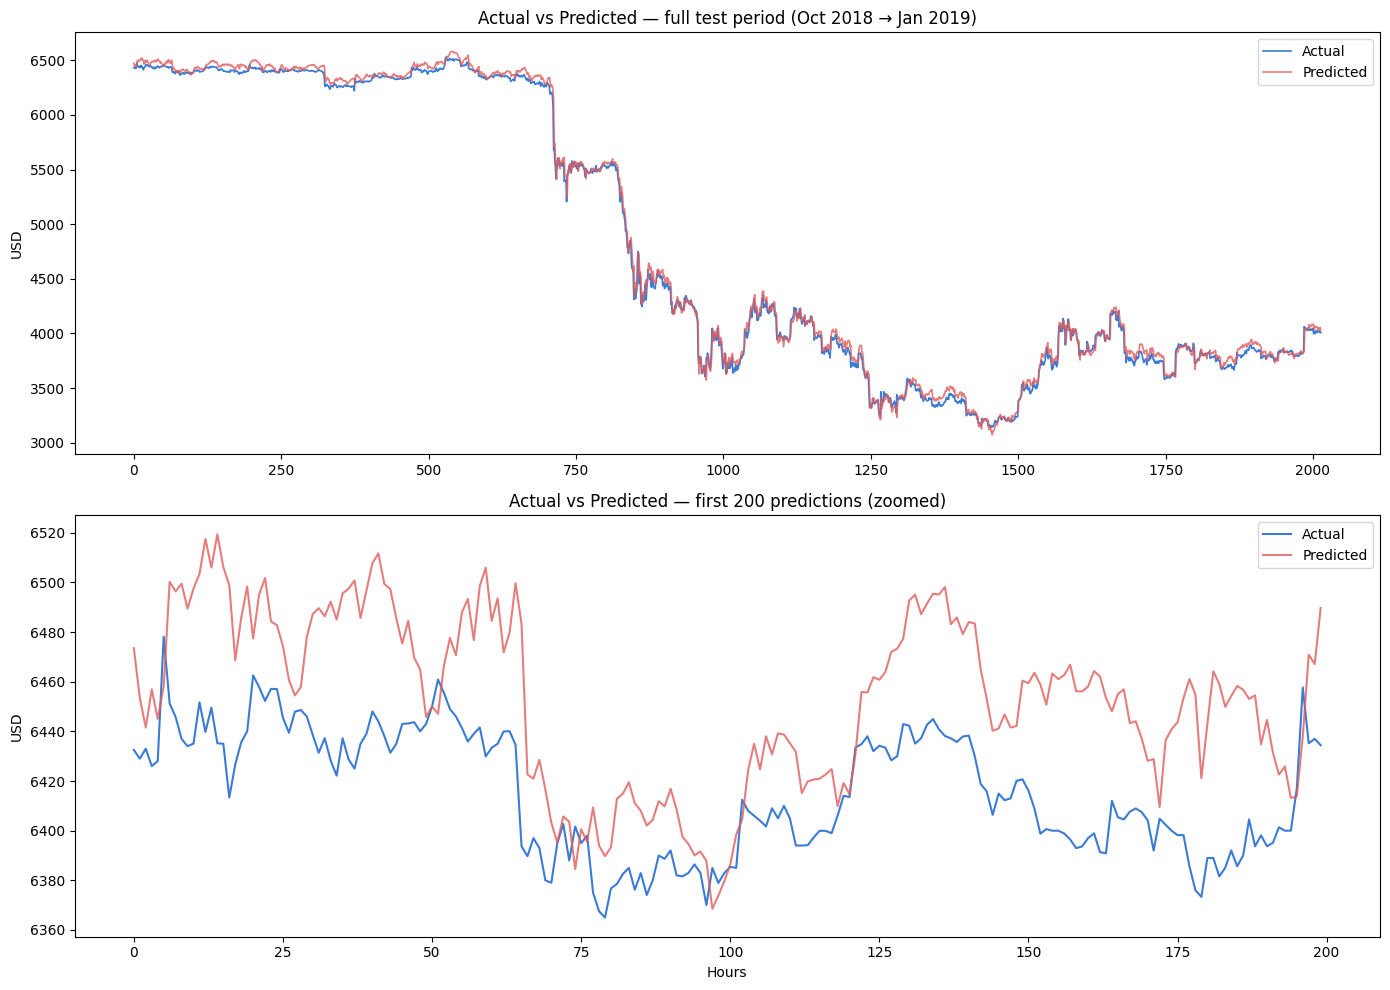

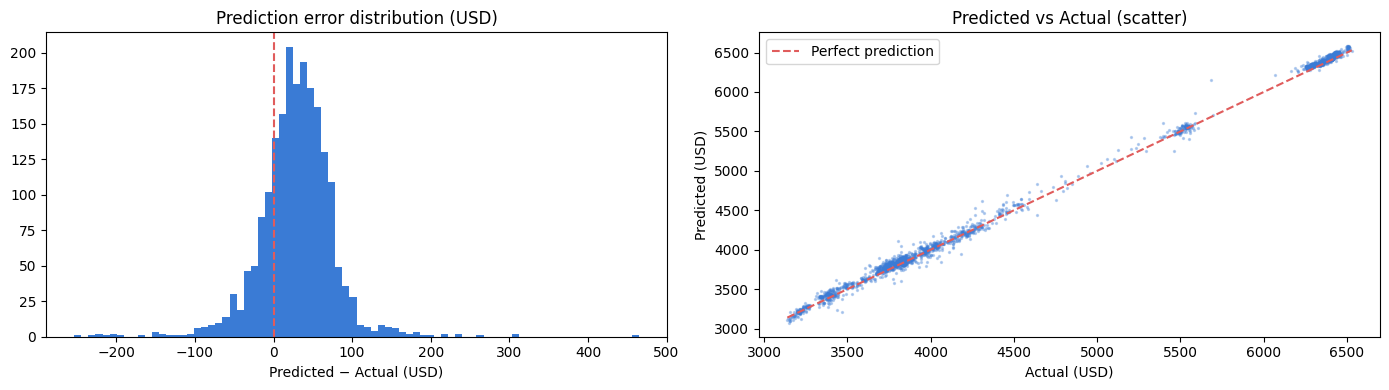

Mean error (bias) : $+29.05
Std of errors     : $47.64


In [ ]:
import matplotlib.pyplot as plt

# We plot from saved predictions instead

# ── Collect predictions and actuals ───────────────────────────
print('Collecting predictions...')
y_pred_scaled = []
y_true_scaled = []

for X_batch, y_batch in test_ds:
    preds = model.predict(X_batch, verbose=0)
    y_pred_scaled.extend(preds.flatten())
    y_true_scaled.extend(y_batch.numpy().flatten())

y_pred_scaled = np.array(y_pred_scaled)
y_true_scaled = np.array(y_true_scaled)

# ── Inverse-transform to USD ───────────────────────────────────
def inverse_transform_close(scaled_values, scaler, close_idx=0, n_features=6):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, close_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, close_idx]

y_pred_usd = inverse_transform_close(y_pred_scaled, scaler)
y_true_usd = inverse_transform_close(y_true_scaled, scaler)

# ── Plot actual vs predicted ───────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full test period
axes[0].plot(y_true_usd, lw=1.2, color='#3a7bd5', label='Actual')
axes[0].plot(y_pred_usd, lw=1.2, color='#e05c5c', alpha=0.8, label='Predicted')
axes[0].set_title('Actual vs Predicted — full test period (Oct 2018 → Jan 2019)', fontsize=12)
axes[0].set_ylabel('USD')
axes[0].legend()

# Zoom: first 200 predictions
axes[1].plot(y_true_usd[:200], lw=1.5, color='#3a7bd5', label='Actual')
axes[1].plot(y_pred_usd[:200], lw=1.5, color='#e05c5c', alpha=0.8, label='Predicted')
axes[1].set_title('Actual vs Predicted — first 200 predictions (zoomed)', fontsize=12)
axes[1].set_ylabel('USD')
axes[1].set_xlabel('Hours')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Error distribution ─────────────────────────────────────────
errors = y_pred_usd - y_true_usd

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(errors, bins=80, color='#3a7bd5', edgecolor='none')
axes[0].axvline(0, color='#e05c5c', lw=1.5, linestyle='--')
axes[0].set_title('Prediction error distribution (USD)', fontsize=12)
axes[0].set_xlabel('Predicted − Actual (USD)')

axes[1].scatter(y_true_usd, y_pred_usd, s=2, alpha=0.3, color='#3a7bd5')
axes[1].plot([y_true_usd.min(), y_true_usd.max()],
             [y_true_usd.min(), y_true_usd.max()],
             color='#e05c5c', lw=1.5, linestyle='--', label='Perfect prediction')
axes[1].set_title('Predicted vs Actual (scatter)', fontsize=12)
axes[1].set_xlabel('Actual (USD)')
axes[1].set_ylabel('Predicted (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Mean error (bias) : ${errors.mean():+.2f}')
print(f'Std of errors     : ${errors.std():,.2f}')

## Step 8 — Save model and predictions

We save two files for the dashboard notebook:
- `model.keras` — already saved by ModelCheckpoint during training
- `predictions.json` — actual vs predicted prices with timestamps,
  this is what the dashboard will read to render the prediction chart

In [ ]:
import json
import pandas as pd

print('Saving predictions...')

# ── Build predictions JSON ─────────────────────────────────────
# Reconstruct approximate timestamps for the test set
# Each window is shift=60 apart, starting after WINDOW_SIZE + HORIZON rows
test_start_idx = WINDOW_SIZE + HORIZON
timestamps = pd.date_range(
    start='2018-10-15',
    periods=len(y_true_usd),
    freq='60min'
).strftime('%Y-%m-%d %H:%M').tolist()

predictions = {
    'metadata': {
        'window_size'   : WINDOW_SIZE,
        'horizon'       : HORIZON,
        'test_start'    : '2018-10-15',
        'test_end'      : '2019-01-07',
        'mae_usd'       : round(float(np.mean(np.abs(y_pred_usd - y_true_usd))), 2),
        'rmse_usd'      : round(float(np.sqrt(np.mean((y_pred_usd - y_true_usd) ** 2))), 2),
        'mse_scaled'    : round(float(np.mean((y_pred_scaled - y_true_scaled) ** 2)), 8),
        'n_samples'     : len(y_true_usd)
    },
    'data': [
        {
            'timestamp' : timestamps[i],
            'actual'    : round(float(y_true_usd[i]), 2),
            'predicted' : round(float(y_pred_usd[i]), 2),
            'error'     : round(float(y_pred_usd[i] - y_true_usd[i]), 2)
        }
        for i in range(len(y_true_usd))
    ]
}

# ── Save predictions JSON ──────────────────────────────────────
predictions_path = os.path.join(OUT_DIR, 'predictions.json')
with open(predictions_path, 'w') as f:
    json.dump(predictions, f, indent=2)

print(f'  predictions.json saved → {predictions_path}')
print(f'  model.keras      saved → {model_path}')
print()
print('=' * 50)
print('Notebook 3 complete.')
print(f'  Test MAE  : ${predictions["metadata"]["mae_usd"]:,.2f}')
print(f'  Test RMSE : ${predictions["metadata"]["rmse_usd"]:,.2f}')
print(f'  Samples   : {predictions["metadata"]["n_samples"]:,}')
print('=' * 50)
print()
print('Next step → Notebook 4: Dashboard')

Saving predictions...
  predictions.json saved → /content/drive/MyDrive/TimeSeriesForecasting/model/predictions.json
  model.keras      saved → /content/drive/MyDrive/TimeSeriesForecasting/model/model.keras

Notebook 3 complete.
  Test MAE  : $42.57
  Test RMSE : $55.80
  Samples   : 2,014

Next step → Notebook 4: Dashboard


## Summary

Notebook 3 is complete. Here is what we achieved.


### Model architecture
- Input: 1,440 timesteps × 6 features (24 hours of BTC data)
- LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(1)
- Loss: Mean Squared Error — Optimizer: Adam

### Training
- Trained on 2017-01-01 → 2018-06-30
- Early stopping fired at epoch 21, best weights restored from epoch 16
- Validation MAE: ~$52 on Jul-Oct 2018 data

### Test set results
Evaluated on completely unseen data from October 2018 to January 2019.

| Metric | Value |
|--------|-------|
| MSE (scaled) | 0.000008 |
| MAE (USD) | \$42.57 |
| RMSE (USD) | \$55.80 |

An average error of $42 on a price range of \$3,200–\$7,500 represents
approximately 0.6\% of price — strong performance for a baseline LSTM model.

### Output files
| File | Description |
|------|-------------|
| `model/model.keras` | Trained model weights ready for inference |
| `model/predictions.json` | 2,014 actual vs predicted prices with timestamps and metrics |
| `processed/scaler.pkl` | Fitted scaler for inverse-transforming future predictions |

> The dashboard notebook reads `predictions.json` and `model.keras` only.
> No raw data or scaled arrays are needed from this point on.